In [ ]:
import pandas as pd
import numpy as np
import re # regular expressions
import matplotlib.pyplot as plt
import seaborn as sns
import nltk # for basics
from nltk.corpus import stopwords # to remove be verbs uwnated words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [ ]:
# load required nltk files
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("vader_lexicon")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [ ]:
df.head()

,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product. Worth the money.


In [ ]:
stop_words = set(stopwords.words("english"))
def clean_text(text):

  # covert to lowercase
  text = text.lower()
  print("lower case", text)

  #remove special characters and numbers
  text = re.sub(r'[^a-zA-Z\s]', "", text) # Corrected regex to remove non-alphabetic/non-whitespace
  print("remove special characters and numbers", text)

#tokenization
  words = word_tokenize(text)
  print("tokenization", words)

#reomve stopwords
  words = [word for word in words if word not in stop_words]
  print("stopwords", words)

#join words again
  cleaned_text= " ".join(words)

  return " ".join(words)



# apply cleaning function
df["cleaned_review"] = df["Review"].apply(clean_text)

print("\nCleaned Reviews")
print(df[["Review", "cleaned_review"]]) # Corrected column name to 'cleaned_review'

lower case the product quality is excellent and delivery was very fast.
remove special characters and numbers the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
remove special characters and numbers very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
remove special characters and numbers customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
remove special characters and numbers the deliv

In [ ]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score ["compound"]
  if compound >= 0.05:
    return "Positive"
  elif compound<= -0.05:
    return "Negative"
  else:
    return "Neutral"
# apply sentiment analysis
df["Sentiment"] = df["cleaned_review"].apply(analyze_sentiment)

print("\nSentiment Analysis")
print(df[["Review", "Sentiment"]])




Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [ ]:
all_words =" ".join(df["cleaned_review"])

word_list = all_words.split()

#count word frequency
word_freq = Counter(word_list)

#display top 10 keywords
print("\nTop 10 common keywords")
print(word_freq.most_common(10))



Top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
negative_reviews = df[df["Sentiment"]=="Negative"]

negative_words=" ".join(negative_reviews["cleaned_review"])

negative_word_list = negative_words.split()

negative_word_freq = Counter(negative_word_list)

print("\nTop 10 common negative keywords")
print(negative_word_freq.most_common(10))



Top 10 common negative keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


/tmp/ipykernel_4315/2489435862.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="viridis")


Text(0, 0.5, 'Count')

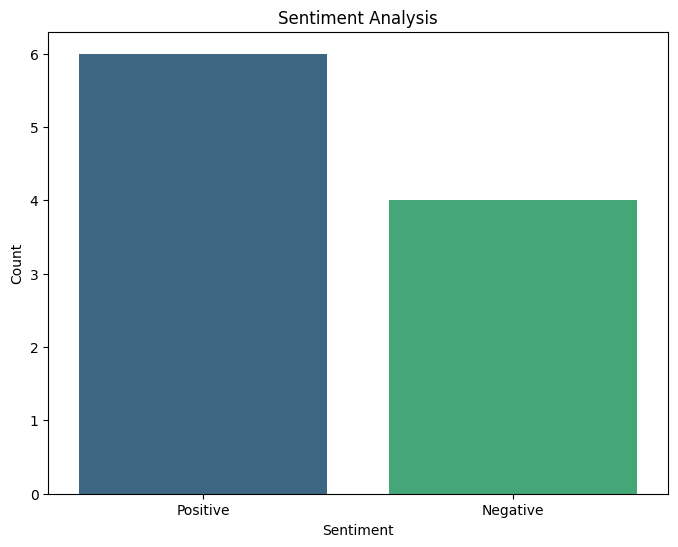

In [ ]:
sentiment_count = df["Sentiment"].value_counts()#it will give category count

plt.figure(figsize=(8,6))
sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="viridis")
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")

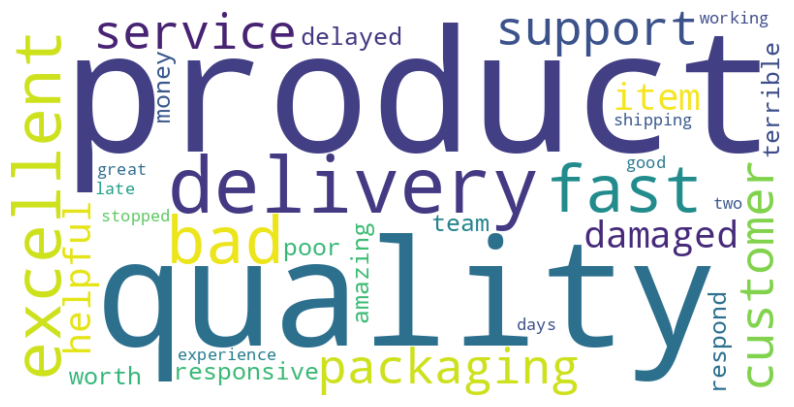

In [ ]:
#word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    ).generate(all_words)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
